Streaming output truncated to the last 5000 lines.
. . . . . . . . . . . . . . . H . . . . . . . . . . . . . . . .
. . . . . . . . . . . . . . . . H . . . . . . . . . . . . . . .
. . . . . . . . . . . . . . . . . H . . . . . . . . . . . . . .
. . . . . . . . . . . . . . . . . . H . . . . . . . . . . . . .
. . . . . . . . . . . . . . . . . . . H . . . . . . . . . . . .
. . . . . . . . . . . . . . . . . . . . H . . . . . . . . . . .
. . . . . . . . . . . . . . . . . . . . . H . . . . . . . . . .
. . . . . . . . . . . . . . . . . . . . . . H . . . . . . . . .
. . . . . . . . . . . . . . . . . . . . . . . H . . . . . . . .
. . . . . . . . . . . . . . . . . . . . . . . . H . . . . . . .
. . . . . . . . . . . . . . . . . . . . . . . . . H . . . . . .
. . . . . . . . . . . . . . . . . . . . . . . . . . H . . . . .
. . . . . . . . . . . . . . . . . . . . . . . . . . . H . . . .
. . . . . . . . . . . . . . . . . . . . . . . . . . . . H . . .
. . . . . . . . . . . . . . . . . . . . . . . . . . .

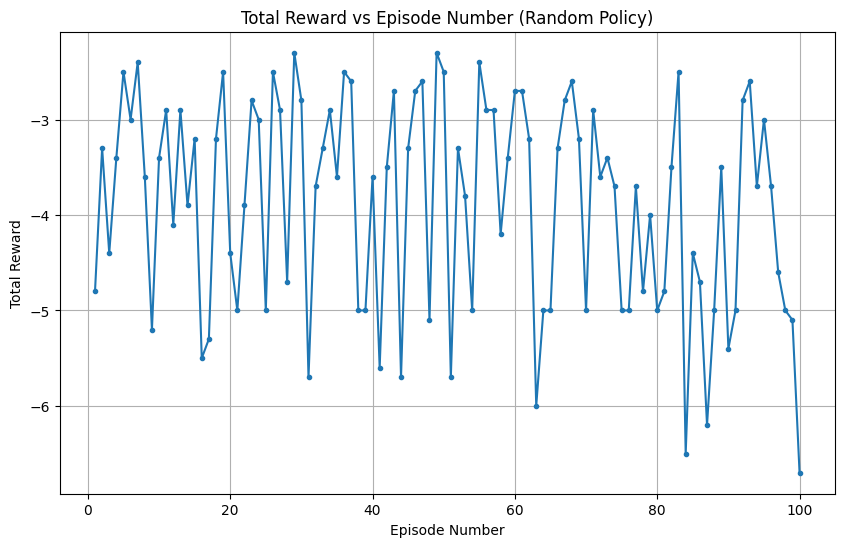


Average Total Reward over 100 episodes: -3.88


In [9]:
#q1

import numpy as np
#import gym
import gymnasium as gym
import random
from gymnasium import Env, spaces
import matplotlib.pyplot as plt

class CustomFrozenlayoutEnv(Env):
    def __init__(self, grid_size=4, slip_probability=0.2, max_steps=50):
        super(CustomFrozenlayoutEnv, self).__init__()

        #define grid size
        self.grid_size = grid_size
        self.slip_probability = slip_probability
        self.max_steps = max_steps
        self.current_steps = 0

        # action spaces : 0 - left ; 1 - down ; 2 - right ; 3 - up
        self.action_space = spaces.Discrete(4)

        # observation space where each state corresponds to a grid cell
        self.observation_space = spaces.Discrete(grid_size * grid_size)

        # define layout layout 1: 0 = frozen, 1 = hole, 2 = goal
        self.layout = np.zeros((grid_size, grid_size), dtype=int)
        self.layout[-1, -1] = 2  # Goal

        #holes
        for i in range(2, grid_size):
            for j in range(2, grid_size):
                if i==j:  #generate holes on all diags for simplicity
                    self.layout[i, j] = 1

        #starting state
        self.start_pos = (0, 0)
        self.state = (0, 0)

    def step(self, action):
        x, y = self.state  #read current state

        # Check if current position is frozen and apply slip condition BEFORE moving
        if self.layout[x, y] == 0 and random.random() < self.slip_probability:
            action = self.action_space.sample()  # Agent slips - random action

        # move agent based on action (original or slipped)
        if action == 0:  # Left
            y = max(0, y - 1)
        elif action == 1:  # Down
            x = min(self.grid_size - 1, x + 1)
        elif action == 2:  # Right
            y = min(self.grid_size - 1, y + 1)
        elif action == 3:  # Up
            x = max(0, x - 1)

        #state updation
        self.state = (x, y)
        self.current_steps += 1

        #calculate rewards
        reward = -0.1  # Small negative reward for each step

        if self.layout[x, y] == 1:  #penalty for falling into hole
            reward = -2
        if self.layout[x, y] == 2:
            reward = 1

        # termination check
        done = (self.layout[x, y] == 2 or
                self.layout[x, y] == 1 or
                self.current_steps >= self.max_steps)

        # return all info
        return self._get_state_index(), reward, done, {}

    def reset(self):
        self.state = self.start_pos
        self.current_steps = 0
        return self._get_state_index()

    def render(self):
        grid = np.array(self.layout, dtype=str)
        grid[self.layout == 0] = "."
        grid[self.layout == 1] = "H"
        grid[self.layout == 2] = "G"
        x, y = self.state
        grid[x, y] = "A"  # agent
        print("\n".join(" ".join(row) for row in grid))

    def _get_state_index(self):
        return self.state[0] * self.grid_size + self.state[1]

env = CustomFrozenlayoutEnv(grid_size=32, slip_probability=0.2, max_steps=50)

episodes = 100
total_rewards = []

for epi in range(episodes):
    state = env.reset()
    done = False
    total_reward = 0
    steps = 0

    print(f"\nEpisode: {epi + 1}\n")
    env.render()

    while not done:
        action = env.action_space.sample()
        next_state, reward, done, info = env.step(action)
        total_reward += reward
        steps += 1

        action_names = ["Left", "Down", "Right", "Up"]
        print(f"\nAction: {action_names[action]}")
        env.render()
        print(f"\nReward: {reward}")

        #check termination condition
        if reward == -2:
            print("\nAgent fell into the cliff")
        elif reward == 1:
            print("\nAgent achieved the goal!")
        elif env.current_steps >= env.max_steps:
            print("\nEpisode terminated due to steps crossing the limit")

    total_rewards.append(total_reward)
    print(f"\nTotal Reward for Episode {epi + 1}: {total_reward}")

#plot
plt.figure(figsize=(10, 6))
plt.plot(range(1, episodes + 1), total_rewards, marker='o', linestyle='-', markersize=3)
plt.xlabel('Episode Number')
plt.ylabel('Total Reward')
plt.title('Total Reward vs Episode Number (Random Policy)')
plt.grid(True)
plt.show()

print(f"\nAverage Total Reward over {episodes} episodes: {np.mean(total_rewards):.2f}")

In [11]:
#q2

import numpy as np
import gymnasium as gym
from gymnasium import Env, spaces
import matplotlib.pyplot as plt

class CustomMountainCarEnv(Env):
    def __init__(self, min_position=-1.2, max_position=0.6, max_speed=0.07,
                 goal_position=0.5, force=0.0015, gravity=0.0025, min_steps=10, max_steps=200):
        super(CustomMountainCarEnv, self).__init__()

        # environment parameters
        self.min_position = min_position
        self.max_position = max_position
        self.max_speed = max_speed
        self.goal_position = goal_position
        self.force = force
        self.gravity = gravity
        self.min_steps = min_steps
        self.max_steps = max_steps

        # action space: 0 - push left, 1 - no action, 2 - push right
        self.action_space = spaces.Discrete(3)

        # observation space: [position, velocity]
        self.observation_space = spaces.Box(
            low=np.array([self.min_position, -self.max_speed], dtype=np.float32),
            high=np.array([self.max_position, self.max_speed], dtype=np.float32),
            dtype=np.float32
        )

        # state variables
        self.state = None
        self.current_steps = 0

    def reset(self):
        # initialize car at bottom of valley with zero velocity
        self.state = np.array([-0.5, 0.0], dtype=np.float32)
        self.current_steps = 0
        return self.state

    def step(self, action):
        position, velocity = self.state

        # apply transition dynamics
        # v_t+1 = v_t + (a_t - 1) * F + g * cos(3 * x_t)
        velocity += (action - 1) * self.force + self.gravity * np.cos(3 * position)

        # clip velocity to allowed range
        velocity = np.clip(velocity, -self.max_speed, self.max_speed)

        # update position
        position += velocity

        # clip position to allowed range
        position = np.clip(position, self.min_position, self.max_position)

        # if car hits left boundary, reset velocity to zero
        if position == self.min_position and velocity < 0:
            velocity = 0.0

        # update state
        self.state = np.array([position, velocity], dtype=np.float32)
        self.current_steps += 1

        # reward function: -1 for each step
        reward = -1

        # check termination conditions
        done = False
        if position >= self.goal_position and self.current_steps >= self.min_steps:
            done = True
        elif self.current_steps >= self.max_steps:
            done = True

        return self.state, reward, done, {}

    def render(self):
        position, velocity = self.state
        print(f"position: {position:.4f}, velocity: {velocity:.4f}, steps: {self.current_steps}")

# create environment
env = CustomMountainCarEnv(min_steps=10, max_steps=200)

# run one episode with random policy
episodes = 1

for epi in range(episodes):
    state = env.reset()
    done = False
    total_reward = 0

    print(f"\nepisode {epi + 1} started")
    print(f"initial state - position: {state[0]:.4f}, velocity: {state[1]:.4f}")

    while not done:
        # random action
        action = env.action_space.sample()

        # take step
        next_state, reward, done, info = env.step(action)
        total_reward += reward

        # action names
        action_names = ["push left", "no action", "push right"]

        # display step info
        print(f"\naction: {action_names[action]}")
        env.render()
        print(f"reward: {reward}")

        # check if goal reached
        if done and next_state[0] >= env.goal_position:
            print("\ngoal reached!")
        elif done and env.current_steps >= env.max_steps:
            print("\nmax steps reached")

    print(f"\ntotal reward for episode {epi + 1}: {total_reward}")
    print(f"final position: {next_state[0]:.4f}, final velocity: {next_state[1]:.4f}")


episode 1 started
initial state - position: -0.5000, velocity: 0.0000

action: no action
position: -0.4998, velocity: 0.0002, steps: 1
reward: -1

action: push right
position: -0.4980, velocity: 0.0019, steps: 2
reward: -1

action: push right
position: -0.4944, velocity: 0.0035, steps: 3
reward: -1

action: push left
position: -0.4922, velocity: 0.0023, steps: 4
reward: -1

action: no action
position: -0.4897, velocity: 0.0025, steps: 5
reward: -1

action: push right
position: -0.4854, velocity: 0.0043, steps: 6
reward: -1

action: push left
position: -0.4824, velocity: 0.0030, steps: 7
reward: -1

action: push right
position: -0.4775, velocity: 0.0048, steps: 8
reward: -1

action: no action
position: -0.4723, velocity: 0.0052, steps: 9
reward: -1

action: no action
position: -0.4667, velocity: 0.0056, steps: 10
reward: -1

action: no action
position: -0.4607, velocity: 0.0060, steps: 11
reward: -1

action: push left
position: -0.4558, velocity: 0.0050, steps: 12
reward: -1

action: n